# This notebook demonstrates the use of `data_preprocessing.py` to process EEG data and `cnn_lstm.py` for building a CNN-LSTM classifier.
Note: Due to runtime nondeterminism in Google Colab, accuracy may vary between sessions.This run achieves ~65% test accuracy.

In [ ]:
!pip install keras==3.13.2

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout, Conv2D, LSTM, BatchNormalization, MaxPooling2D, Reshape
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/Colab Notebooks/cvae_project/"
    os.chdir(base_path)
else:
    base_path = "."

Mounted at /content/drive


## (i) Loading the Data

In [5]:
# ----------------------------
# Loading Data
# ----------------------------
X_test = np.load(base_path + "data/X_test.npy")
y_test = np.load(base_path + "data/y_test.npy")
person_train_valid = np.load(base_path +"data/person_train_valid.npy")
X_train_valid = np.load(base_path +"data/X_train_valid.npy")
y_train_valid = np.load(base_path +"data/y_train_valid.npy")
person_test = np.load(base_path +"data/person_test.npy")

## (ii) Preprocessing the dataset and preparing the training, validation, and test datasets

In [6]:
from src.preprocessing import data_prep as dp


In [7]:

# ----------------------------
#  Data Pre-Processing - dp.prepare_dataset (mode = 'cnn') for CNN_LSTM, CNN_LSTM_RESIDUAL
# ----------------------------
y_train_valid -= 769
y_test -= 769

x_train, x_valid, x_test, y_train, y_valid, y_test = dp.prepare_dataset(
    X_train_valid, y_train_valid, X_test, y_test, mode='cnn'
)

Shape of X after trimming: (1740, 22, 500)
Shape of X after maxpooling: (1740, 22, 250)
Shape of X after averaging+noise and concatenating: (3480, 22, 250)
Shape of X after subsampling and concatenating: (6960, 22, 250)
Shape of X after trimming: (375, 22, 500)
Shape of X after maxpooling: (375, 22, 250)
Shape of X after averaging+noise and concatenating: (750, 22, 250)
Shape of X after subsampling and concatenating: (1500, 22, 250)
Shape of X after trimming: (443, 22, 500)
Shape of X after maxpooling: (443, 22, 250)
Shape of X after averaging+noise and concatenating: (886, 22, 250)
Shape of X after subsampling and concatenating: (1772, 22, 250)
Shape of testing set: (1772, 22, 250)
Shape of testing labels: (1772,)
Shape of training set: (6960, 22, 250)
Shape of validation set: (1500, 22, 250)
Shape of training labels: (6960,)
Shape of validation labels: (1500,)
Shape of training labels after categorical conversion: (6960, 4)
Shape of validation labels after categorical conversion: (15

## (iii) Loading the CNN-LSTM model and training for 50 epochs

In [8]:
from src.models import cnn_lstm


In [9]:
model = cnn_lstm.CNN_LSTM(input_shape=(250, 1, 22))
learning_rate = 1e-3
model.compile(loss='categorical_crossentropy',
                  optimizer=keras.optimizers.Adam(learning_rate),
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
cnn_lstm_results = model.fit(x_train,
             y_train,
             batch_size=64,
             epochs=50,
             validation_data=(x_valid, y_valid), verbose=True)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step - accuracy: 0.2664 - loss: 1.3955 - val_accuracy: 0.2973 - val_loss: 1.3720
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - accuracy: 0.3234 - loss: 1.3669 - val_accuracy: 0.3527 - val_loss: 1.3251
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 202ms/step - accuracy: 0.3848 - loss: 1.3149 - val_accuracy: 0.3853 - val_loss: 1.2902
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - accuracy: 0.4079 - loss: 1.2762 - val_accuracy: 0.4160 - val_loss: 1.2634
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - accuracy: 0.4254 - loss: 1.2502 - val_accuracy: 0.4393 - val_loss: 1.2425
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.4428 - loss: 1.2166 - val_accuracy: 0.4613 - val_loss: 1.2206
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.4635 - loss: 1.1858 - val_accuracy: 0.4527 - val_loss: 1.2377
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 215ms/step - accuracy: 0.4737 - loss: 1

## (iv) Visualization and assessment of the model

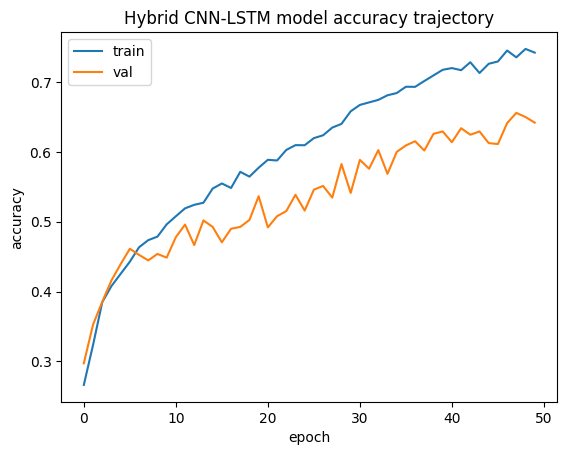

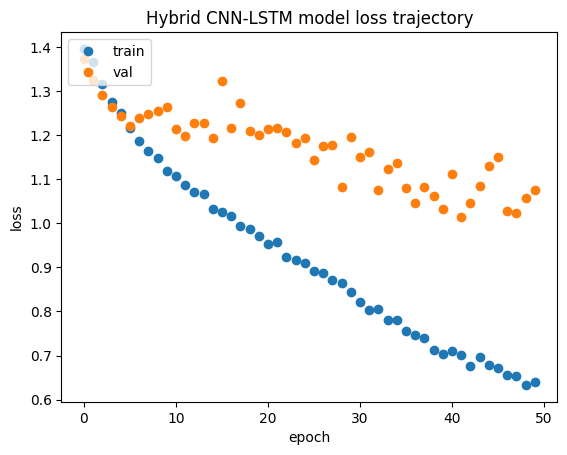

In [11]:
# Plotting accuracy trajectory
plt.plot(cnn_lstm_results.history['accuracy'])
plt.plot(cnn_lstm_results.history['val_accuracy'])
plt.title('Hybrid CNN-LSTM model accuracy trajectory')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Plotting loss trajectory
plt.plot(cnn_lstm_results.history['loss'],'o')
plt.plot(cnn_lstm_results.history['val_loss'],'o')
plt.title('Hybrid CNN-LSTM model loss trajectory')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [13]:

cnn_lstm_score = model.evaluate(x_test, y_test, verbose=0)
print('Test accuracy of the hybrid CNN-LSTM model:',cnn_lstm_score[1])

Test accuracy of the hybrid CNN-LSTM model: 0.6597065329551697
